In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Load Data From Kaggle
https://www.kaggle.com/datasets/datascikhan/e-commerce-customer-segmentation-2026

In [49]:
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download(
    "datascikhan/e-commerce-customer-segmentation-2026"
)
print(f"Dataset path: {path}")

data_dir = Path(path)
csv_files = sorted(data_dir.rglob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {data_dir}")

df = pd.read_csv(csv_files[0])
print(f"Loaded file: {csv_files[0].name}")
print(f"Rows: {len(df):,} | Columns: {df.shape[1]:,}")

Dataset path: /Users/yezawmyint/.cache/kagglehub/datasets/datascikhan/e-commerce-customer-segmentation-2026/versions/1
Loaded file: E-commerce_Customer_Segmentation_2026.csv
Rows: 50,000 | Columns: 53


# Understanding data

In [50]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")

print("Column types:")
display(df.dtypes.to_frame("dtype"))

Duplicate rows: 0
Column types:


,dtype
customer_id,str
customer_segment,str
segment_category,str
age,int64
age_group,str
gender,str
country,str
city,str
income_bracket,str
education_level,str


## Check Data Validation

In [51]:
# Missing values
missing = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": (missing / len(df) * 100).round(2)
})
print("*"*30)
print(" Missing Value Summary")
print("*"*30)

display(
    missing_summary
    .sort_values("Missing Values", ascending=False)
    .head(5)
)

******************************
 Missing Value Summary
******************************


,Missing Values,Missing %
preferred_category_3,33257,66.51
preferred_category_2,16743,33.49
social_media_presence,12420,24.84
loyalty_tier,1272,2.54
customer_id,0,0.00


## Outliers Detection

In [52]:
numeric_data = df.select_dtypes(include="number")
q1 = numeric_data.quantile(0.25)
q3 = numeric_data.quantile(0.75)
iqr = q3 - q1

outlier_summary = pd.DataFrame({
    "Lower Limit": q1 - 1.5 * iqr,
    "Upper Limit": q3 + 1.5 * iqr,
    "Outliers": ((numeric_data < q1 - 1.5 * iqr) | (numeric_data > q3 + 1.5 * iqr)).sum(),
}).sort_values("Outliers", ascending=False)

outlier_summary.round(2).head(8)

,Lower Limit,Upper Limit,Outliers
days_since_last_purchase,-110.50,189.50,6460
customer_profitability_usd,-91480.50,193461.62,1080
customer_lifetime_value_usd,-91350.69,193554.21,1078
total_spent_usd,-80482.92,171187.74,582
customer_health_score,37.50,137.50,263
rfm_score,4.00,20.00,174
churn_risk_score,-35.00,85.00,140
age,-15.00,105.00,0


In [53]:
outlier_data = df[["total_spent_usd"]].dropna()
model = IsolationForest(contamination=0.01, random_state=42)
outlier_labels = model.fit_predict(outlier_data)

outlier_rows = df.loc[outlier_data.index[outlier_labels == -1]]
print(f"Isolation Forest outliers: {len(outlier_rows):,}")
display(outlier_rows.head(20))

Isolation Forest outliers: 499


,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
20,CUST-000021,Consumer,High Value Inactive,82,65+,Female,Spain,Zaragoza,0-25K,High School,...,Very High,Active,Excellent,Very Low,Champions,High Profit,Medium,Regular Buyer,Multi-Device,High CLV
28,CUST-000029,Consumer,High Value Active,28,25-34,Male,India,Ahmedabad,25K-50K,Masters,...,Very High,Active,Excellent,Low,Champions,High Profit,Medium,Frequent Buyer,Mobile-First,High CLV
52,CUST-000053,Consumer,High Value Active,40,35-44,Male,Canada,Vancouver,75K-100K,Bachelors,...,Very High,Active,Good,Low,Champions,High Profit,Medium,Frequent Buyer,Desktop-First,High CLV
96,CUST-000097,Consumer,High Value Active,39,35-44,Female,India,Chennai,75K-100K,Professional,...,Very High,Active,Excellent,Very Low,Champions,High Profit,Low,Frequent Buyer,Multi-Device,High CLV
212,CUST-000213,Premium,High Value Inactive,52,45-54,Female,France,Strasbourg,50K-75K,PhD,...,Very High,At Risk,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Mobile-First,High CLV
320,CUST-000321,Small Business,High Value Inactive,67,65+,Male,Japan,Sapporo,0-25K,Professional,...,Very High,Active,Good,Medium,Champions,High Profit,High,Regular Buyer,Mobile-First,High CLV
807,CUST-000808,Small Business,High Value Inactive,36,35-44,Male,Netherlands,Amsterdam,50K-75K,PhD,...,Very High,Inactive,Fair,Medium,Loyal,High Profit,High,Occasional Buyer,Mobile-First,High CLV
935,CUST-000936,Small Business,High Value Inactive,64,55-64,Male,Singapore,Singapore,150K+,PhD,...,Very High,Dormant,Excellent,Very Low,Champions,High Profit,High,Regular Buyer,Mobile-First,High CLV
999,CUST-001000,Consumer,High Value Active,64,55-64,Male,Netherlands,Eindhoven,25K-50K,Bachelors,...,Very High,Active,Excellent,Very Low,Champions,High Profit,Medium,Frequent Buyer,Multi-Device,High CLV
1032,CUST-001033,Consumer,High Value Active,27,25-34,Female,Italy,Genoa,150K+,Masters,...,Very High,Active,Excellent,Very Low,Champions,High Profit,Medium,Frequent Buyer,Multi-Device,High CLV


# Exploratory Data Analysis

This section looks at the customers, their purchase activity, and simple patterns in the data.

## Descriptive Statistics

First, I summarize the main customer and purchase variables before looking at charts.

In [54]:
# Summary Statistic
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,50000.0,45.65,18.37,18.00,30.00,45.00,60.00,84.00
tenure_months,50000.0,59.75,34.31,1.00,30.00,60.00,90.00,119.00
total_purchases,50000.0,99.42,57.78,0.00,49.00,99.00,150.00,199.00
avg_order_value_usd,50000.0,505.37,285.60,10.05,259.07,504.79,752.70,999.99
total_spent_usd,50000.0,50266.55,44071.21,0.00,13893.58,37541.62,76811.24,198574.14
days_since_last_purchase,50000.0,62.97,93.28,0.00,2.00,19.00,77.00,365.00
return_count,50000.0,9.51,5.78,0.00,4.00,10.00,15.00,19.00
complaint_count,50000.0,6.99,4.32,0.00,3.00,7.00,11.00,14.00
satisfaction_score,50000.0,3.01,1.42,1.00,2.00,3.00,4.00,5.00
email_open_rate,50000.0,0.50,0.29,0.00,0.25,0.50,0.75,1.00


### Customer Profile

This part shows who the customers are by age group, gender, income, country, and device.

In [55]:
customer_profile_summary = pd.DataFrame({
    "Metric": [
        "Unique customers",
        "Most common age group",
        "Most common gender",
        "Most common income bracket",
        "Top country",
        "Most used device"
    ],
    "Value": [
        df["customer_id"].nunique(),
        df["age_group"].mode().iat[0],
        df["gender"].mode().iat[0],
        df["income_bracket"].mode().iat[0],
        df["country"].mode().iat[0],
        df["device_used"].mode().iat[0]
    ]
})

display(customer_profile_summary)

,Metric,Value
0,Unique customers,50000
1,Most common age group,65+
2,Most common gender,Female
3,Most common income bracket,0-25K
4,Top country,United States
5,Most used device,Desktop


## Customer Segment Distribution

This chart shows how customers are distributed across the main business segments. The largest segment is highlighted for quick comparison.

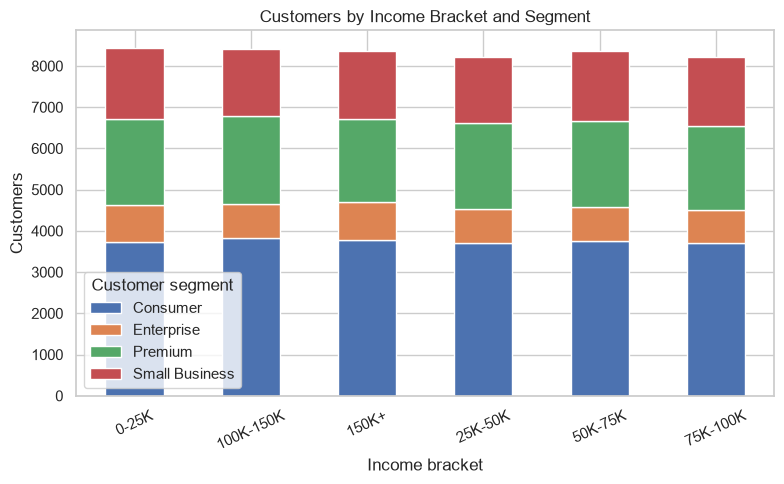

In [56]:
income_segment_counts = pd.crosstab(
    df["income_bracket"],
    df["customer_segment"],
)

income_segment_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
)
plt.title("Customers by Income Bracket and Segment")
plt.xlabel("Income bracket")
plt.ylabel("Customers")
plt.xticks(rotation=25)
plt.legend(title="Customer segment")
plt.tight_layout()
plt.show()

### Purchase Behavior

This part summarizes how often customers purchase, how much they spend, and how recently they purchased.

In [57]:
numeric_purchase_cols = [
    "tenure_months",
    "total_purchases",
    "avg_order_value_usd",
    "total_spent_usd",
    "days_since_last_purchase",
]

purchase_summary = pd.DataFrame({
    "Metric": [
        "Average tenure (months)",
        "Average total purchases",
        "Average order value (USD)",
        "Average total spent (USD)",
        "Average days since last purchase",
    ],
    "Value": [
        df["tenure_months"].mean(),
        df["total_purchases"].mean(),
        df["avg_order_value_usd"].mean(),
        df["total_spent_usd"].mean(),
        df["days_since_last_purchase"].mean(),
    ],
})

purchase_summary["Value"] = purchase_summary["Value"].round(2)
display(purchase_summary)

,Metric,Value
0,Average tenure (months),59.75
1,Average total purchases,99.42
2,Average order value (USD),505.37
3,Average total spent (USD),50266.55
4,Average days since last purchase,62.97


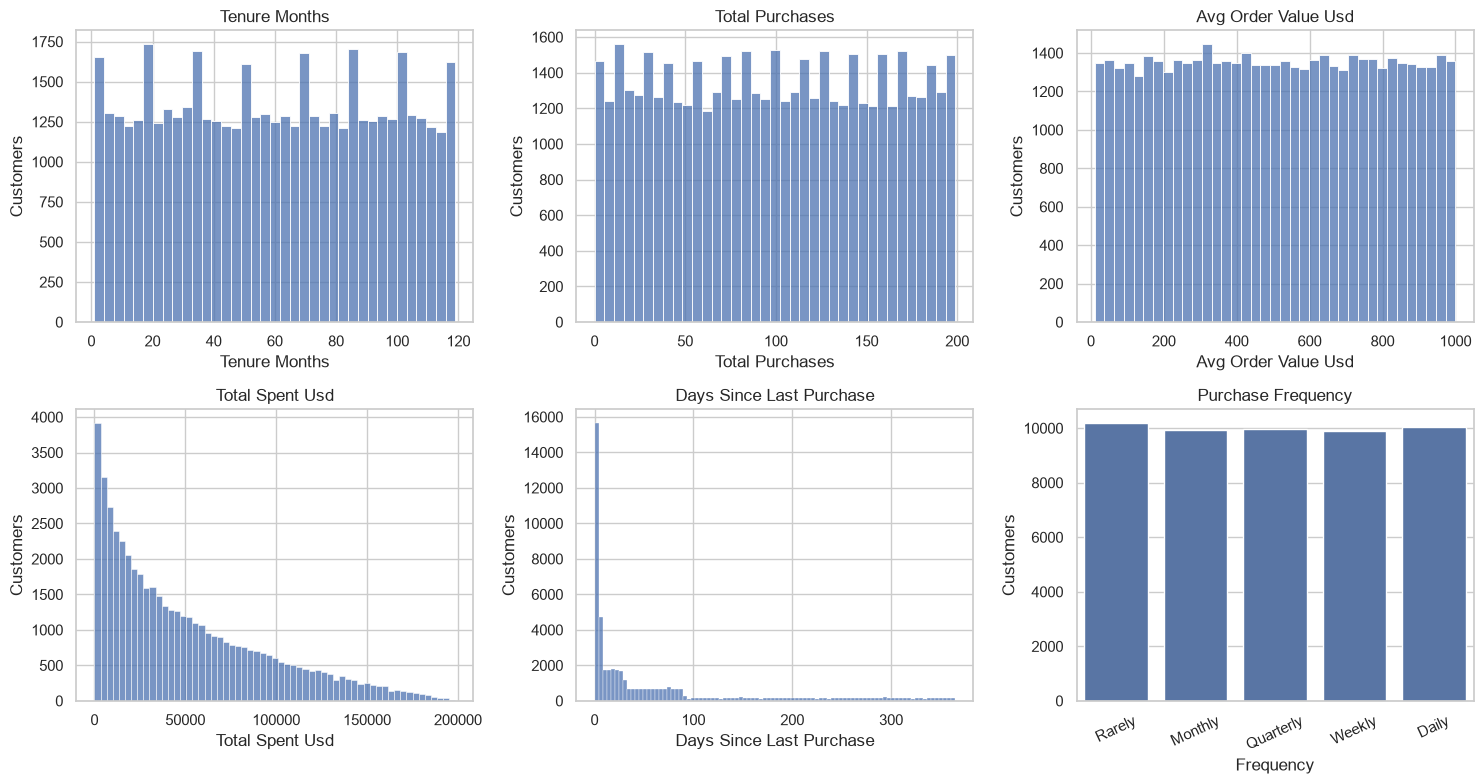

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, column in zip(axes.flat[:5], numeric_purchase_cols):
    sns.histplot(data=df, x=column, ax=ax)
    ax.set_title(column.replace("_", " ").title())
    ax.set_xlabel(column.replace("_", " ").title())
    ax.set_ylabel("Customers")

frequency_order = ["Rarely", "Monthly", "Quarterly", "Weekly", "Daily"]
sns.countplot(
    data=df,
    x="purchase_frequency",
    order=[value for value in frequency_order if value in df["purchase_frequency"].unique()],
    ax=axes[1, 2],
)
axes[1, 2].set_title("Purchase Frequency")
axes[1, 2].set_xlabel("Frequency")
axes[1, 2].set_ylabel("Customers")
axes[1, 2].tick_params(axis="x", rotation=25)

fig.tight_layout()
plt.show()
plt.close(fig)

In [59]:
df[numeric_purchase_cols].corr().round(2)

,tenure_months,total_purchases,avg_order_value_usd,total_spent_usd,days_since_last_purchase
tenure_months,1.0,0.00,0.00,0.00,0.00
total_purchases,0.0,1.00,0.00,0.67,-0.00
avg_order_value_usd,0.0,0.00,1.00,0.65,-0.01
total_spent_usd,0.0,0.67,0.65,1.00,-0.01
days_since_last_purchase,0.0,-0.00,-0.01,-0.01,1.00


In [60]:
frequency_order = {
    "Rarely": 1,
    "Quarterly": 2,
    "Monthly": 3,
    "Weekly": 4,
    "Daily": 5,
}

frequency_numeric = df["purchase_frequency"].astype("string").str.strip().map(frequency_order)

if frequency_numeric.isna().any():
    unexpected = df.loc[
        frequency_numeric.isna(),
        "purchase_frequency",
    ].dropna().unique().tolist()
    raise ValueError(f"Unexpected purchase frequency values: {unexpected}")

df["frequency_group"] = pd.qcut(
    frequency_numeric.rank(method="first"),
    3,
    labels=["Low", "Medium", "High"],
)
df["recency_group"] = pd.qcut(
    df["days_since_last_purchase"],
    3,
    labels=["Recent", "Moderate", "Inactive"],
    duplicates="drop",
)

behavior_summary = (
    df.groupby(["frequency_group", "recency_group"], observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        avg_spent=("total_spent_usd", "mean"),
        avg_order_value=("avg_order_value_usd", "mean"),
    )
    .reset_index()
)

behavior_summary[["avg_spent", "avg_order_value"]] = (
    behavior_summary[["avg_spent", "avg_order_value"]].round(2)
)
display(behavior_summary)

,frequency_group,recency_group,customers,avg_spent,avg_order_value
0,Low,Moderate,2400,50431.53,499.91
1,Low,Inactive,14267,50046.03,504.15
2,Medium,Recent,2304,52083.72,517.58
3,Medium,Moderate,12111,50157.19,506.04
4,Medium,Inactive,2251,51115.70,499.77
5,High,Recent,14774,50146.03,505.16
6,High,Moderate,1893,50138.06,510.57


# Customer Value, Risk, and Segmentation Analysis

The next sections translate the descriptive EDA into actionable customer insights: RFM value, churn risk, profitability, segment performance, and data-driven customer clusters.

In [61]:
required_columns = {
    "customer_id",
    "days_since_last_purchase",
    "total_purchases",
    "total_spent_usd",
    "avg_order_value_usd",
    "customer_segment",
    "churn_risk_category",
    "profitability_category"
}
missing_columns = sorted(required_columns - set(df.columns))
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

rfm = df[[
    "customer_id",
    "days_since_last_purchase",
    "total_purchases",
    "total_spent_usd",
]].rename(
    columns={
        "days_since_last_purchase": "recency",
        "total_purchases": "frequency",
        "total_spent_usd": "monetary",
    }
).copy()

rfm["recency_score"] = pd.qcut(
    rfm["recency"].rank(method="first"),
    q=5,
    labels=[5, 4, 3, 2, 1],
).astype(int)
rfm["frequency_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5],
).astype(int)
rfm["monetary_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5],
).astype(int)
rfm["rfm_score"] = rfm[[
    "recency_score",
    "frequency_score",
    "monetary_score",
]].astype(str).agg("".join, axis=1)

high_recency = rfm["recency_score"] >= 4
low_recency = rfm["recency_score"] <= 2
high_frequency = rfm["frequency_score"] >= 4
low_frequency = rfm["frequency_score"] <= 2
high_monetary = rfm["monetary_score"] >= 4

rfm["rfm_category"] = np.select(
    [
        high_recency & high_frequency & high_monetary,
        high_recency & low_frequency,
        low_recency & high_monetary,
        low_recency & low_frequency,
    ],
    ["Champions", "New or Promising", "At Risk High Value", "Hibernating"],
    default="Loyal Customers",
)

rfm_category_summary = (
    rfm["rfm_category"]
    .value_counts()
    .rename_axis("RFM Category")
    .reset_index(name="Customers")
)
display(rfm_category_summary)

,RFM Category,Customers
0,Loyal Customers,21235
1,New or Promising,8003
2,At Risk High Value,7915
3,Hibernating,7411
4,Champions,5436


## RFM and Customer Value

,customers,avg_recency_days,avg_purchases,avg_spent_usd,avg_annualized_value
calculated_rfm_category,,,,,
Champions,5436,2.25,161.19,106336.43,60294.30
At Risk High Value,7915,144.96,139.81,95656.23,52345.65
Loyal Customers,21235,41.46,112.87,42168.56,22527.88
New or Promising,8003,2.28,39.43,19945.40,11155.33
Hibernating,7411,147.13,37.20,16609.23,8899.57


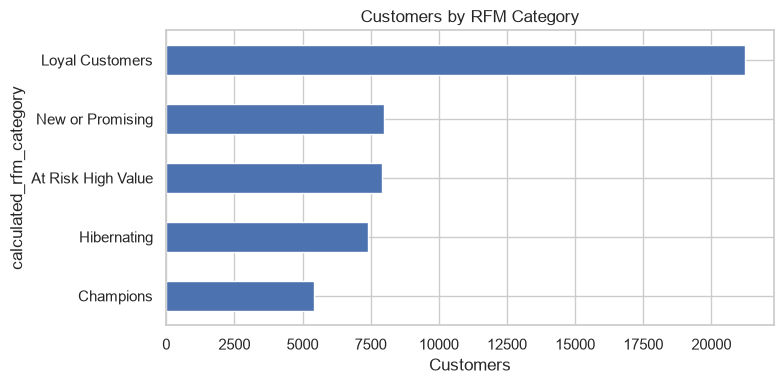

In [62]:
rfm_summary_columns = ["customer_id", "rfm_score", "rfm_category"]
calculated_rfm = rfm[rfm_summary_columns].rename(
    columns={
        "rfm_score": "calculated_rfm_score",
        "rfm_category": "calculated_rfm_category",
    }
)
customer_analysis = df.join(
    calculated_rfm.set_index("customer_id"),
    on="customer_id",
    how="left",
    validate="one_to_one",
)

customer_analysis["annualized_value_proxy"] = (
    customer_analysis["total_spent_usd"]
    .div(customer_analysis["tenure_months"].clip(lower=1))
    .mul(12)
    .round(2)
)

segment_summary = (
    customer_analysis
    .groupby("calculated_rfm_category", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        avg_recency_days=("days_since_last_purchase", "mean"),
        avg_purchases=("total_purchases", "mean"),
        avg_spent_usd=("total_spent_usd", "mean"),
        avg_annualized_value=("annualized_value_proxy", "mean"),
    )
    .sort_values("avg_spent_usd", ascending=False)
    .round(2)
)

display(segment_summary)

segment_summary["customers"].sort_values().plot.barh(figsize=(8, 4), title="Customers by RFM Category")
plt.xlabel("Customers")
plt.tight_layout()
plt.show()

## Churn Risk, Profitability, and Business Actions

These comparisons identify where retention effort and marketing budget are most likely to matter.

,customers,avg_recency_days,avg_total_spent_usd,total_revenue_usd
churn_risk_category,,,,
Very Low,20604,28.37,51552.95,1.062197e+09
Low,17203,60.07,50379.87,8.666849e+08
Medium,9491,109.21,48711.93,4.623250e+08
High,2395,178.55,46331.65,1.109643e+08
Very High,307,216.65,36339.32,1.115617e+07


,customers,avg_total_spent_usd,avg_order_value_usd,avg_purchases
profitability_category,,,,
High Profit,48770,51522.86,511.70,101.68
Medium Profit,514,786.00,243.01,16.32
Low Profit,357,396.83,148.74,9.04
Break Even,61,146.11,54.62,4.85
Loss Making,298,10.02,441.64,0.26


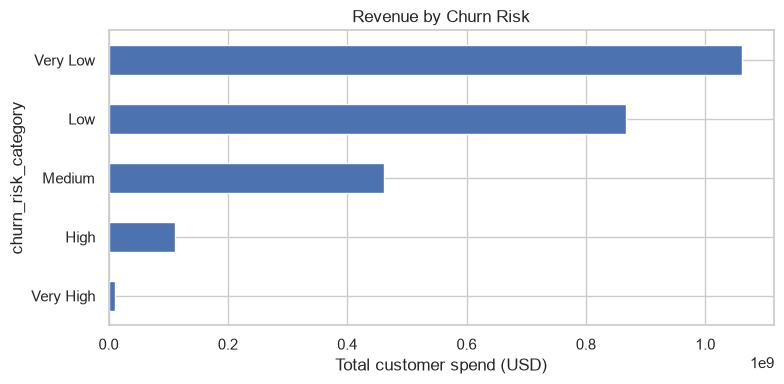

Suggested actions:
- Prioritize high-value customers in elevated churn-risk categories for personalized retention campaigns.
- Nurture New or Promising customers toward repeat purchase behavior.
- Use Champions for referrals, early access, and loyalty advocacy.
- Re-engage Hibernating customers only when the expected campaign value exceeds contact cost.


In [63]:
churn_summary = (
    customer_analysis
    .groupby("churn_risk_category", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        avg_recency_days=("days_since_last_purchase", "mean"),
        avg_total_spent_usd=("total_spent_usd", "mean"),
        total_revenue_usd=("total_spent_usd", "sum"),
    )
    .sort_values("total_revenue_usd", ascending=False)
    .round(2)
)

profitability_summary = (
    customer_analysis
    .groupby("profitability_category", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        avg_total_spent_usd=("total_spent_usd", "mean"),
        avg_order_value_usd=("avg_order_value_usd", "mean"),
        avg_purchases=("total_purchases", "mean"),
    )
    .sort_values("avg_total_spent_usd", ascending=False)
    .round(2)
)

display(churn_summary)
display(profitability_summary)

churn_summary["total_revenue_usd"].sort_values().plot.barh(
    figsize=(8, 4),
    title="Revenue by Churn Risk",
)
plt.xlabel("Total customer spend (USD)")
plt.tight_layout()
plt.show()

print("Suggested actions:")
print("- Prioritize high-value customers in elevated churn-risk categories for personalized retention campaigns.")
print("- Nurture New or Promising customers toward repeat purchase behavior.")
print("- Use Champions for referrals, early access, and loyalty advocacy.")
print("- Re-engage Hibernating customers only when the expected campaign value exceeds contact cost.")

## Customer Clustering Experiment

K-means provides an exploratory, data-driven alternative to the source segment labels. The clusters are descriptive and should be validated with business outcomes before production use.

,customers,avg_recency_days,avg_purchases,avg_order_value_usd,avg_total_spent_usd
behavior_cluster,,,,,
2,13313,38.06,151.15,734.88,109489.44
3,6576,270.20,92.94,471.46,42282.78
4,13361,28.54,42.75,658.28,28787.07
1,16750,28.89,106.06,214.28,23463.81


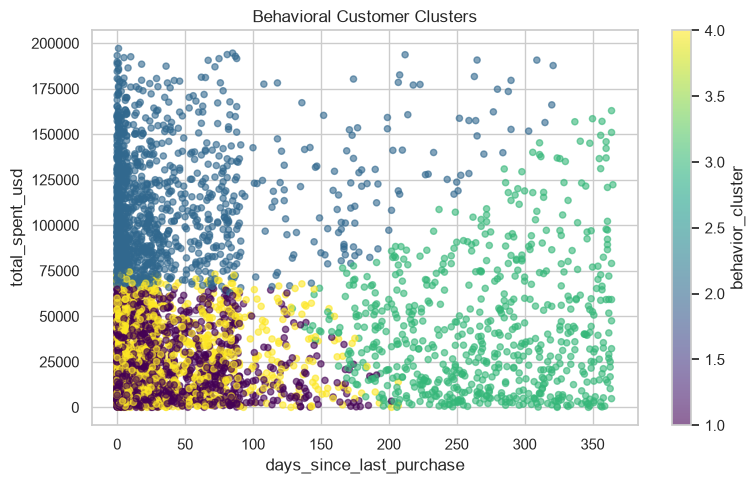

In [64]:
cluster_features = [
    "days_since_last_purchase",
    "total_purchases",
    "avg_order_value_usd",
    "total_spent_usd",
]

if customer_analysis[cluster_features].isna().any().any():
    raise ValueError("Cluster features contain missing values")

scaled_features = StandardScaler().fit_transform(customer_analysis[cluster_features])
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_analysis["behavior_cluster"] = kmeans.fit_predict(scaled_features) + 1

cluster_profile = (
    customer_analysis
    .groupby("behavior_cluster", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        avg_recency_days=("days_since_last_purchase", "mean"),
        avg_purchases=("total_purchases", "mean"),
        avg_order_value_usd=("avg_order_value_usd", "mean"),
        avg_total_spent_usd=("total_spent_usd", "mean"),
    )
    .sort_values("avg_total_spent_usd", ascending=False)
    .round(2)
)

display(cluster_profile)

customer_analysis.sample(
    min(5000, len(customer_analysis)),
    random_state=42,
).plot.scatter(
    x="days_since_last_purchase",
    y="total_spent_usd",
    c="behavior_cluster",
    colormap="viridis",
    alpha=0.6,
    figsize=(8, 5),
    title="Behavioral Customer Clusters",
)
plt.tight_layout()
plt.show()

## Executive Summary

In [65]:
total_customers = customer_analysis["customer_id"].nunique()
total_revenue = customer_analysis["total_spent_usd"].sum()
champions = customer_analysis["calculated_rfm_category"].eq("Champions").sum()
at_risk = customer_analysis["calculated_rfm_category"].eq("At Risk High Value").sum()
high_churn_revenue = churn_summary.loc[
    churn_summary.index.isin(["High", "Very High"]),
    "total_revenue_usd"
].sum()

print("=" * 65)
print("E-COMMERCE CUSTOMER SEGMENTATION: EXECUTIVE SUMMARY")
print("=" * 65)
print(f"Customers analyzed: {total_customers:,}")
print(f"Total historical customer spend: ${total_revenue:,.2f}")
print(f"Champions: {champions:,} ({champions / total_customers:.1%})")
print(f"High-value customers at risk: {at_risk:,} ({at_risk / total_customers:.1%})")
print(
    "Revenue from High and Very High churn-risk customers: "
    f"${high_churn_revenue:,.2f} ({high_churn_revenue / total_revenue:.1%})"
)

key_interpretations = [
    "Champions combine recent activity, high purchase frequency, and the highest average spend.",
    "At Risk High Value customers are the clearest retention priority because their spend remains high despite poor recency.",
    "Hibernating customers have both low purchase frequency and low spend, so broad discounts may be inefficient.",
    "Clusters support differentiated messaging, but stability and campaign response should be tested before deployment."
]
print("\nKey interpretation:")
for number, interpretation in enumerate(key_interpretations, start=1):
    print(f"{number}. {interpretation}")

recommended_next_analyses = [
    "Test retention campaigns with an A/B design and measure incremental revenue.",
    "Build a supervised churn model using a time-based validation split.",
    "Estimate CLV with margin, retention probability, and discount cost rather than revenue alone.",
    "Monitor segment migration monthly to detect changes in loyalty and churn risk."
]
print("\nRecommended next analyses:")
for recommendation in recommended_next_analyses:
    print(f"- {recommendation}")
print("=" * 65)

E-COMMERCE CUSTOMER SEGMENTATION: EXECUTIVE SUMMARY
Customers analyzed: 50,000
Total historical customer spend: $2,513,327,307.80
Champions: 5,436 (10.9%)
High-value customers at risk: 7,915 (15.8%)
Revenue from High and Very High churn-risk customers: $122,120,469.06 (4.9%)

Key interpretation:
1. Champions combine recent activity, high purchase frequency, and the highest average spend.
2. At Risk High Value customers are the clearest retention priority because their spend remains high despite poor recency.
3. Hibernating customers have both low purchase frequency and low spend, so broad discounts may be inefficient.
4. Clusters support differentiated messaging, but stability and campaign response should be tested before deployment.

Recommended next analyses:
- Test retention campaigns with an A/B design and measure incremental revenue.
- Build a supervised churn model using a time-based validation split.
- Estimate CLV with margin, retention probability, and discount cost rather tha